## 1.1 課題と目的

#### 課題
- 例えば、コイン投げにおいて以下の3つのケースを考える。

>- 10回中7回表が出た
>- 100回中70回表が出た
>- 1000回中700回表が出た

- いずれも表が出た割合は0.7であり、最尤推定値も0.7となる。しかし、10回中7回と1000回中700回では、推定値に対する確信度は同じではない。
- このように、標本数が少ない場合、観測された成功率だけを見ても、その推定値をどの程度信頼してよいか判断しづらい。
- また、サンプル数が少ない場合、観測値に対して過去データやドメイン知識をどのように推定に反映するかも重要になる。 例えば、「このコインは普通のコインに近いはずだ」という事前知識を置くかどうかで、より適切な推定をすることはできるだろうか。

#### 目的
- 本プロジェクトでは、コイン投げを題材に、最尤法（MLE）・最大事後確率法（MAP）・ベイズ推定を比較する。

- 特に、以下の点を確認する。
>- MLE・MAP・ベイズ推定の違いを整理する
>- 同じ成功率でも、標本数によって不確実性がどう変わるかを確認する
>- 事前分布の方向や強さによって、事後分布がどう変わるかを確認する
>- 標本数が大きくなると、事前分布の影響がどのように小さくなるかを確認する

| 手法               | 何を求めるか          | 説明                  |
| ---------------- | --------------- | ----------------------- |
| **最尤法（MLE）**     | 尤度が最大になるパラメータ   | **観測データが最も起こりやすくなるパラメータ**を求める方法         |
| **最大事後確率法（MAP）** | 事後分布が最大になるパラメータ |**観測データと事前分布を踏まえて、事後分布が最も高くなるパラメータ**を求める方法     |
| **ベイズ推定**        | 事後分布そのもの        | **観測データと事前分布を踏まえて、パラメータの事後分布そのもの**を求める方法 |

#### ゴール
- A/BテストのCVR比較、広告施策のクリック率推定、少数レビューの商品評価など、少数データから意思決定を行う場面で必要な知識を身に付ける。


## 1.2 結論
- MLEは観測データから1つの推定値を求めるため、同じ成功率であれば標本数が異なっても同じ推定値になる。
- MAPは事後分布が最大となるパラメータを求めるため、事前分布や標本数の影響を反映する。
- ベイズ推定は点推定ではなく事後分布を扱うため、信用区間の導出や推定の不確実性の可視化ができる。
- 標本数が少ないとき、事前分布の影響を強くうける。このとき、事前分布は過去データやドメイン知識を推定に反映するための仕組みとして解釈できる。
- 標本数が増えるほど、事前分布の影響は相対的に小さくなり、観測データの影響が支配的になる。

## 2.1 問題設定
- あるコインを n 回投げたところ、k 回表が出た。このコインの表が出る確率 p を推定。
- 各試行は独立で、表が出る確率は常に p とする。
- このとき、表が出る回数 k は二項分布に従う。（k ~ Binomial(n, p)）


## 2.2 実例
* n = 10, k = 7 のケースを検討する。

## 3.1 最尤推定

- 最尤推定では、観測データ X が得られる確率を最も大きくするパラメータ Θ を求める。

- 観測データ X に対する尤度は、次のように表される。

> L(Θ) = P(X|Θ)

- ここで、P(X|Θ) は、パラメータ Θ のもとで観測データ X が得られる確率である。

- 最尤推定では、この尤度 L(Θ) が最大となる Θ を推定値として求める。

> Θ_MLE = argmax P(X|Θ)

## 3.2 尤度/最尤推定値の可視化
- 10回中7回表と100回中70回表は、どちらも最尤推定値はp=0.7となる。  
- しかし、尤度関数を可視化すると、100回中70回表の方がp=0.7付近に鋭く集中する。
- このことから、同じ最尤推定値であっても、サンプルサイズによって推定の不確実性が異なることが分かる。

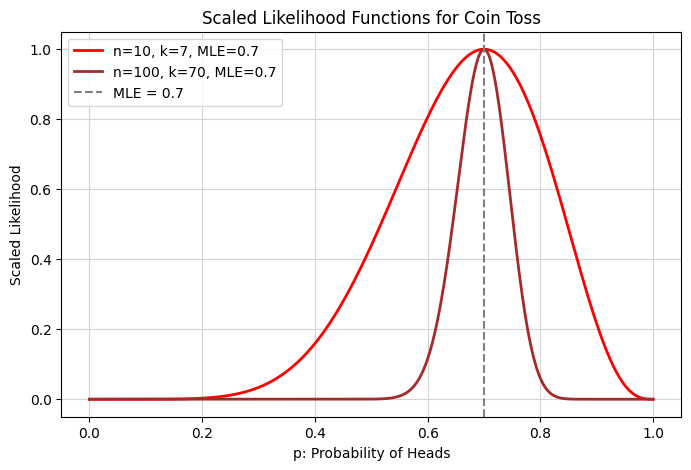

In [1]:
from math import comb
import numpy as np
import matplotlib.pyplot as plt

# 最尤推定
def maximum_likelihood_estimation(n, k):
    MLE = k / n
    return MLE

# 二項分布における尤度： C(n,k)* p^k * p^(1-k)
def Likelihood(n, k, p):
    Likelihood = comb(n,k) * (p**k) * ((1-p)**(n-k))
    return Likelihood

# pの範囲を定める
p = np.linspace(0,1,1001)

cases = [
    (10, 7, 'red'),
    (100, 70, 'brown'),
]

plt.figure(figsize=(8, 5))

for n, k, color in cases:
    likelihood = Likelihood(n, k, p)
    # 正規化して比較
    likelihood_scaled = likelihood / likelihood.max()    
    # 最尤推定値
    mle = maximum_likelihood_estimation(n, k)
    # 尤度関数を描画
    plt.plot(
        p,
        likelihood_scaled,
        label=f'n={n}, k={k}, MLE={mle:.1f}',
        color=color,
        linewidth=2
    )

# 最尤推定値を示す
plt.axvline(
    mle,
    color='gray',
    linestyle='--',
    linewidth=1.5,
    label='MLE = 0.7'
)

plt.xlabel('p: Probability of Heads')
plt.ylabel('Scaled Likelihood')
plt.title('Scaled Likelihood Functions for Coin Toss')
plt.grid(True, color='lightgray')
plt.legend()
plt.show()

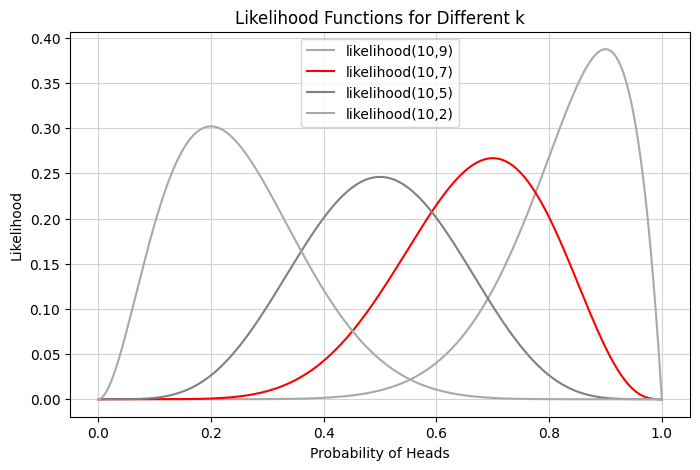

In [2]:
# n=10 のもとで、kを変えたときの尤度を可視化
n = 10
k_cases = [9, 7, 5, 2]

colors = {
    9: 'darkgrey',
    7: 'red',
    5: 'gray',
    2: 'darkgrey'
}

plt.figure(figsize=(8, 5))

for k in k_cases:
    plt.plot(
        p,
        Likelihood(n, k, p),
        label=f'likelihood({n},{k})',
        color=colors[k]
    )

plt.xlabel('Probability of Heads')
plt.ylabel('Likelihood')
plt.title('Likelihood Functions for Different k')
plt.legend()
plt.grid(True, color='lightgray')
plt.show()

## 4.1 最大事後確率法（MAP） 
- MAPでは、事前分布と観測データから得られる事後分布を考え、その事後分布が最大になるpを推定値とする。
- 詳細は、「5.ベイズ推定」にて補足

------(補足)------
- Beta(1, 1) のとき: MLE と MAP は同じ
- Beta(1, 1) 以外の事前分布のとき: 基本的には MLE と MAP はズレる

## 5.1 ベイズ推定
- ベイズ推定では、観測データ X を得た後のパラメータ Θ の分布である事後分布 P(Θ|X) を求める。

>  P(Θ|X) = P(X|Θ) P(Θ) / P(X)

- ここで、P(Θ) は事前分布、P(X|Θ) は尤度、P(X) は周辺尤度(エビデンス)である。
- P(X) は事後分布を確率分布として正規化するための項でもある。

- つまり、事前分布 P(Θ) を、観測データ X に対する尤度 P(X|Θ) によって更新することで、事後分布 P(Θ|X) を得る。

## 5.2 事前分布
- ベイズ推定では、観測データを見る前に、パラメータ Θ に対する事前分布 P(Θ) を仮定する。(コイン投げでは、Θ は「表が出る確率」)
- Θ について強い事前知識を置かない場合、一様分布に対応する Beta(1,1) を事前分布として用いることが多い。（Beta(1,1) は0から1の範囲で一様な分布になり、「表が出る確率 Θ について、特定の値を強く仮定しない」事前分布として解釈可能。）
- Beta分布はベルヌーイ分布・二項分布に対する共役事前分布であり、事後分布もBeta分布になる。

#### Beta分布
- Beta分布は、0から1の範囲をとる確率 p に対する分布である。

> p ~ Beta(a, b)

- 確率密度関数は以下で表される。

> f(p) = 1 / B(a,b) * p^(a-1) * (1-p)^(b-1)

- ここで、


> - a > 0, b > 0
> - B(a,b) はベータ関数
> - 1 / B(a,b) は分布全体の面積を1にするための正規化定数
> - a は成功側の事前的な重み, b は失敗側の事前的な重み (実際に観測した成功回数・失敗回数ではなく、観測前にどの程度成功・失敗を想定しているかを表すパラメータ)


観測データとして、成功 k 回、失敗 n-k 回を得た場合、事後分布は次のようになる。

> p | X ~ Beta(a+k, b+n-k)

-★β分布の事後分布の導出

## 5.3 尤度
- 観測データに対する尤度は、最尤推定で用いた二項分布の確率関数と同じ形で表される。
  
> L(p) = C(n, k) * p^k * (1-p)^(n-k)

- ベイズ更新では、p に依存する部分が事後分布の形を決めるため、pに依存しないC(n,k)は定数として扱える。
- したがって、比例関係としては次のように書ける。

> L(p) ∝ p^k *  (1-p)^(n-k)

## 5.4 事後分布

- ベイズ推定では、尤度を用いて事前分布を更新し、事後分布を得る。
- 事後分布は、尤度と事前分布の積に比例する。

> 事後分布 ∝ 尤度 × 事前分布

- 事前分布を p ~ Beta(a, b)、観測データを n回中k回成功とすると、事後分布は次のようになる。

> p | k ~ Beta(a + k, b + n - k)

## 5.5 実装（事前分布・事後分布・MAP）

事前分布：Beta(1,1)
事後分布：Beta(8,4)
MAP: 0.700


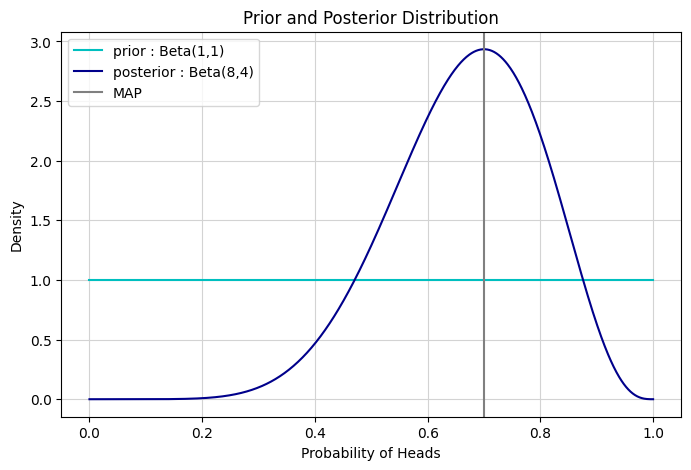

In [3]:
import numpy as np
from scipy.stats import beta
import matplotlib.pyplot as plt

# 観測データ
n = 10
k = 7

# 事前分布 Beta(1,1)を仮定 
a_prior = 1
b_prior = 1
print(f'事前分布：Beta({a_prior},{b_prior})')

# 事後分布 Beta(a+k,b+n-k)
a_post = a_prior + k
b_post = b_prior + (n-k)
print(f'事後分布：Beta({a_post},{b_post})')

# pの候補
p = np.linspace(0,1,1001)

# 確率密度を計算する
# pdf: probability density function
# Beta(a,b)における、x(各点)の高さを返す
prior_pdf = beta.pdf(p, a_prior, b_prior)
post_pdf = beta.pdf(p, a_post, b_post)

# MAP推定（事後確率が最大となるパラメータpの点推定）
map = (a_post - 1) / (a_post + b_post - 2)
print(f'MAP: {map:.3f}')

plt.figure(figsize=(8, 5))
# 描画
plt.plot(
    p,
    prior_pdf,
    label = f'prior : Beta({a_prior},{b_prior})',
    color = 'c'
)
plt.plot(
    p,
    post_pdf,
    label = f'posterior : Beta({a_post},{b_post})',
    color = 'darkblue' 
)
plt.axvline(map, color='gray',label='MAP')
plt.xlabel('Probability of Heads')
plt.ylabel('Density')
plt.title('Prior and Posterior Distribution')
plt.grid(True, color='lightgray')
plt.legend()
plt.show()

## 5.6 実装（信用区間）
- Beta事後分布から、累積確率が2.5%および97.5%となる点を求め、中央95%信用区間を算出。
- この区間は、観測データと事前分布を踏まえたとき、表が出る確率pが95%の確率で含まれる範囲として解釈できる。

下側2.5%点:  0.39
上側97.5%点:  0.891


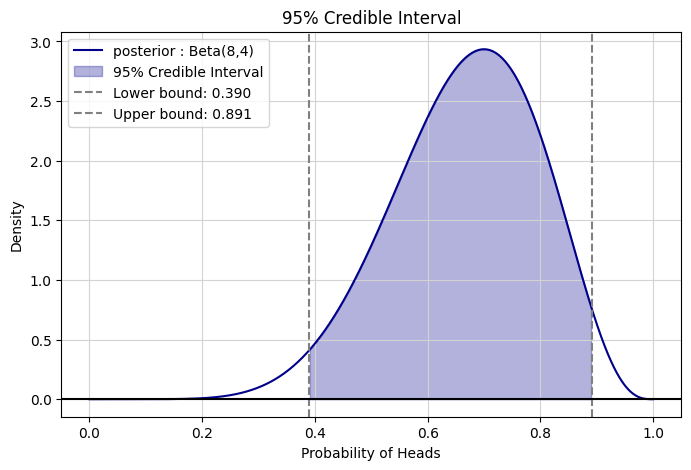

In [4]:
# ppf: percent point function
# Beta事後分布の累積確率が2.5%, 97.5%となるpの値を返す
lower, upper = beta.ppf([0.025, 0.975], a_post, b_post)
print('下側2.5%点: ', round(lower,3))
print('上側97.5%点: ', round(upper,3))

# pの候補
p = np.linspace(0,1,1001)

plt.figure(figsize=(8, 5))
# 事後分布の描画
plt.plot(
    p,
    post_pdf,
    label = f'posterior : Beta({a_post},{b_post})',
    color = 'darkblue' 
)

# 塗りつぶし
mask = (p >= lower) & (p <= upper)
plt.fill_between(
    p[mask],
    post_pdf[mask],
    alpha=0.3,
    label='95% Credible Interval',
    color = 'darkblue' 
)

# 信用区間の描画
plt.axvline(
    lower, 
    linestyle='--', 
    color = 'gray', 
    label=f'Lower bound: {lower:.3f}'
)
plt.axvline(
    upper, 
    linestyle='--', 
    color = 'gray', 
    label=f'Upper bound: {upper:.3f}'
)
plt.axhline(0, color='black')
plt.xlabel('Probability of Heads')
plt.ylabel('Density')
plt.title('95% Credible Interval')
plt.grid(True, color='lightgray')
plt.legend()
plt.show()

## 6.1 検証（標本数）

- 標本数の異なる3つのケースを比較する。

> - 7/10
> - 70/100
> - 700/1000

- いずれも最尤推定値は0.7である。(MAPも同様)
- 一方で、ベイズ推定では標本数が大きくなるほど事後分布の幅が狭くなり、95%信用区間も狭くなる。
- この結果から、同じ点推定値であっても、データ量によって推定の不確実性が異なることが確認できる。

7/10 heads 下側2.5%点:  0.39 / 上側97.5%点:  0.891
70/100 heads 下側2.5%点:  0.604 / 上側97.5%点:  0.781
700/1000 heads 下側2.5%点:  0.671 / 上側97.5%点:  0.728


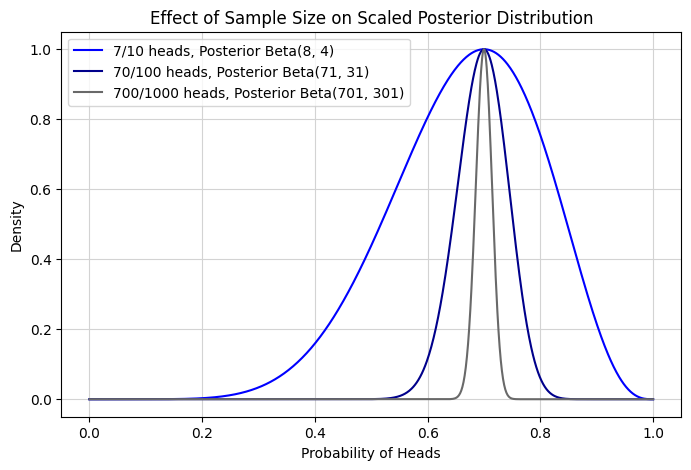

In [5]:
# 事前分布
a_prior = 1
b_prior = 1

# 表が出る割合が0.7となる3つのケースを作成
sample_size_cases = [
    (7, 10),
    (70, 100),
    (700, 1000)
]

p = np.linspace(0, 1, 1000)

# 描画する
colors = ['b', 'darkblue', 'dimgray']

plt.figure(figsize=(8, 5))
for i, (k, n) in enumerate(sample_size_cases):
    a_post = a_prior + k
    b_post = b_prior + (n - k)
    
    posterior_pdf = beta.pdf(p, a_post, b_post)
    scaled_psoterior_pdf = posterior_pdf / posterior_pdf.max()
    
    plt.plot(
        p,
        scaled_psoterior_pdf,
        color=colors[i],
        label=f'{k}/{n} heads, Posterior Beta({a_post}, {b_post})'
    )

    lower, upper = beta.ppf([0.025, 0.975], a_post, b_post)
    print(f'{k}/{n} heads','下側2.5%点: ', round(lower,3), '/','上側97.5%点: ', round(upper,3))

plt.xlabel('Probability of Heads')
plt.ylabel('Density')
plt.title('Effect of Sample Size on Scaled Posterior Distribution')
plt.legend()
plt.grid(True, color='lightgray')
plt.show()

## 6.2 検証（事前分布の方向・強さの影響）
【n=10, k=7 の観測データに対して、事前分布を変えた場合の事後分布を比較】
- 同じ観測データであっても、事前分布の設定によって事後分布の位置や幅が変化することが確認できた。
- 標本数が小さい場合、事前分布の影響も大きく反映される。このとき、事前分布は単なる主観ではなく、過去データやドメイン知識を反映するための仕組みとして解釈できる。
- また、強い事前分布を置くほど、事後分布は事前分布の影響を強く受ける。
- 10回中7回程度の成功を事前分布で表すとき、Beta(7,3)とBeta（7+1,3+1)のどちらを使用？ → 7.補足へ

【n=1000, k=700 の観測データに対して、事前分布を変えた場合の事後分布を比較】
- 標本数が大きい時、事前分布を変えても、事後分布は観測データから得られる MLE = 0.7 付近に集中する。

Prior: Beta(1, 1) MAP: 0.700 下側2.5%点:  0.39 / 上側97.5%点:  0.891
Prior: Beta(5, 5) MAP: 0.611 下側2.5%点:  0.384 / 上側97.5%点:  0.797
Prior: Beta(7, 3) MAP: 0.722 下側2.5%点:  0.488 / 上側97.5%点:  0.874
Prior: Beta(8, 4) MAP: 0.700 下側2.5%点:  0.478 / 上側97.5%点:  0.854
Prior: Beta(2, 8) MAP: 0.444 下側2.5%点:  0.244 / 上側97.5%点:  0.665
Prior: Beta(100, 100) MAP: 0.510 下側2.5%点:  0.442 / 上側97.5%点:  0.577


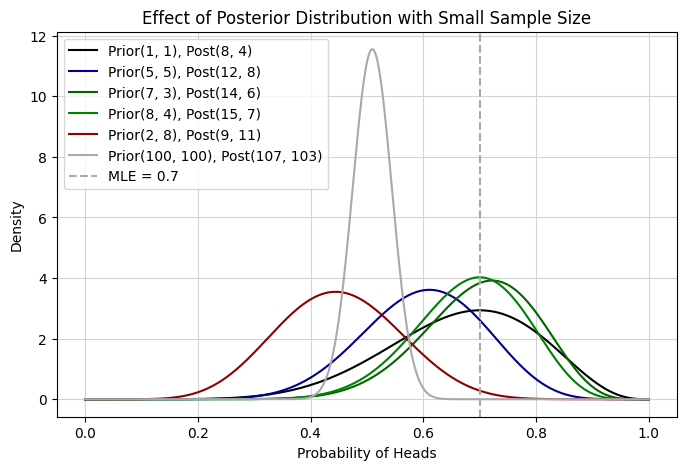

In [6]:
# 事前分布を仮定
prior_cases = [
    (1, 1),      # 事前知識なし
    (5, 5),      # 普通のコイン寄り
    (7, 3),      # 平均的な成功確率が0.7
    (8, 4),      # 事前にコインが10回投げて7回表が出ることを想定
    (2, 8),      # 裏が出やすい
    (100,100)    # 強い事前分布
]

# 観測値
n = 10
k = 7
MLE = k / n

# pを設定
p = np.linspace(0, 1, 1000)

# 描画する
colors = ['black', 'darkblue', 'darkgreen','green', 'darkred', 'darkgray']

plt.figure(figsize=(8, 5))
for i, (a_prior, b_prior) in enumerate(prior_cases):
    a_post = a_prior + k
    b_post = b_prior + (n - k)
    
    # MAP推定（事後確率が最大となるパラメータpの点推定）
    map = (a_post - 1) / (a_post + b_post - 2)
    
    posterior_pdf = beta.pdf(p, a_post, b_post)
    
    plt.plot(
        p,
        posterior_pdf,
        color=colors[i],
        label=f'Prior({a_prior}, {b_prior}), Post({a_post}, {b_post})'
    )

    lower, upper = beta.ppf([0.025, 0.975], a_post, b_post)
    print(f'Prior: Beta({a_prior}, {b_prior})',f'MAP: {map:.3f}','下側2.5%点: ', round(lower,3), '/','上側97.5%点: ', round(upper,3))

plt.axvline(
    MLE,
    color='darkgray',
    linestyle='--',
    linewidth=1.5,
    label=f'MLE = {MLE:.1f}'
)

plt.xlabel('Probability of Heads')
plt.ylabel('Density')
plt.title('Effect of Posterior Distribution with Small Sample Size')
plt.legend()
plt.grid(True, color='lightgray')
plt.show()

Prior: Beta(1, 1) MAP: 0.700 下側2.5%点:  0.39 / 上側97.5%点:  0.891
Prior: Beta(5, 5) MAP: 0.611 下側2.5%点:  0.384 / 上側97.5%点:  0.797
Prior: Beta(7, 3) MAP: 0.722 下側2.5%点:  0.488 / 上側97.5%点:  0.874
Prior: Beta(8, 4) MAP: 0.700 下側2.5%点:  0.478 / 上側97.5%点:  0.854
Prior: Beta(2, 8) MAP: 0.444 下側2.5%点:  0.244 / 上側97.5%点:  0.665
Prior: Beta(100, 100) MAP: 0.510 下側2.5%点:  0.442 / 上側97.5%点:  0.577


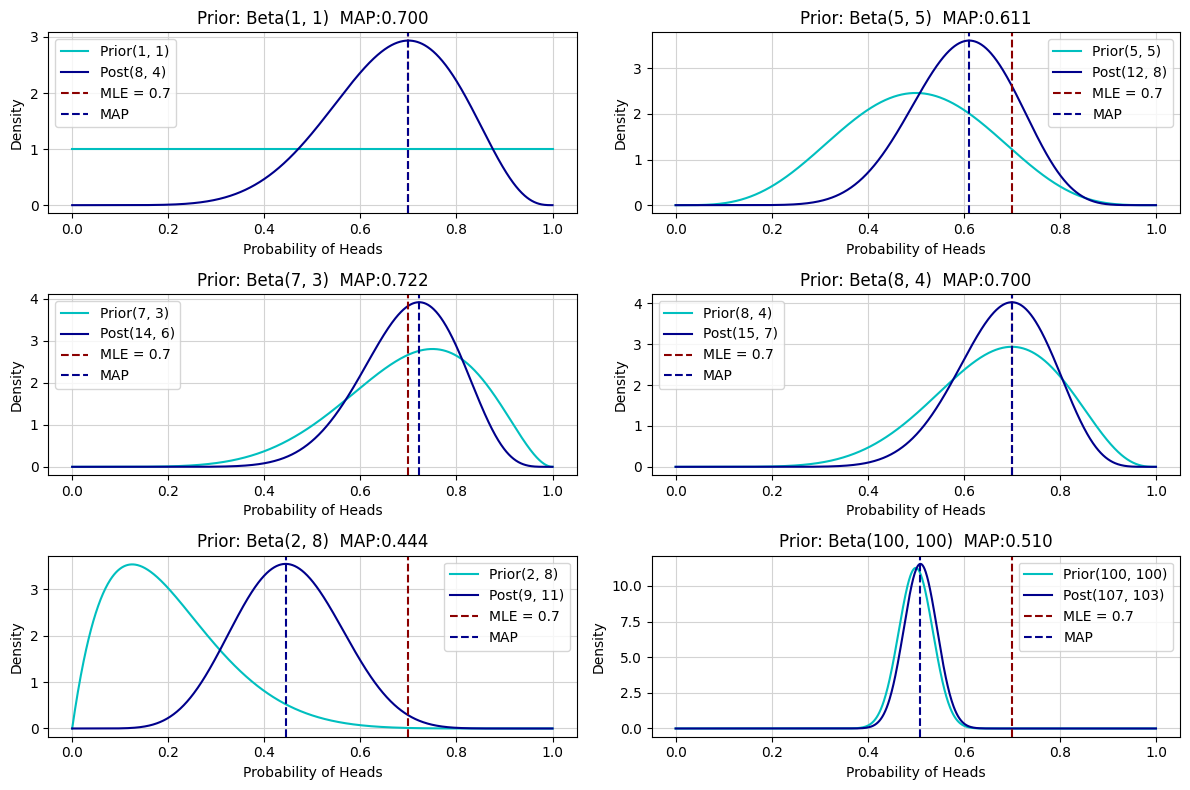

In [7]:
# 事前分布を仮定
prior_cases = [
    (1, 1),      # 事前知識なし
    (5, 5),      # 普通のコイン寄り
    (7, 3),      # 平均的な成功確率が0.7
    (8, 4),      # 事前にコインが10回投げて7回表が出ることを想定
    (2, 8),      # 裏が出やすい
    (100,100)    # 強い事前分布
]

# 観測値
n = 10
k = 7

# pを設定
p = np.linspace(0, 1, 1000)

# 2×2の描画領域を作成
fig, axes = plt.subplots(3, 2, figsize=(12, 8))

# axesを1次元に変換してループで扱いやすくする
axes = axes.ravel()

for i, (a_prior, b_prior) in enumerate(prior_cases):
    a_post = a_prior + k
    b_post = b_prior + (n - k)
    
    prior_pdf = beta.pdf(p, a_prior, b_prior)
    posterior_pdf = beta.pdf(p, a_post, b_post)

    # MAP推定（事後確率が最大となるパラメータpの点推定）
    map = (a_post - 1) / (a_post + b_post - 2)

    lower, upper = beta.ppf([0.025, 0.975], a_post, b_post)

    # 各subplotに描画
    ax = axes[i]

    ax.plot(
        p,
        prior_pdf,
        color='c',
        label=f'Prior({a_prior}, {b_prior})'
    )
    
    ax.plot(
        p,
        posterior_pdf,
        color='darkblue',
        label=f'Post({a_post}, {b_post})'
    )

    print(f'Prior: Beta({a_prior}, {b_prior})',f'MAP: {map:.3f}','下側2.5%点: ', round(lower,3), '/','上側97.5%点: ', round(upper,3))

    ax.axvline(
        MLE,
        color='darkred',
        linestyle='--',
        linewidth=1.5,
        label=f'MLE = {MLE:.1f}'
    )
    ax.set_xlabel('Probability of Heads')
    ax.set_ylabel('Density')
    ax.set_title(f'Prior: Beta({a_prior}, {b_prior})  MAP:{map:.3f}')
    # ax.set_ylim(-0.2, 4.1)
    ax.grid(True, color='lightgray')
    ax.axvline(map, color='darkblue',label='MAP',linestyle='--')
    ax.legend()

plt.tight_layout()
plt.show()

Prior: Beta(1, 1) MAP: 0.700 下側2.5%点:  0.671 / 上側97.5%点:  0.728
Prior: Beta(5, 5) MAP: 0.698 下側2.5%点:  0.669 / 上側97.5%点:  0.726
Prior: Beta(7, 3) MAP: 0.700 下側2.5%点:  0.671 / 上側97.5%点:  0.728
Prior: Beta(8, 4) MAP: 0.700 下側2.5%点:  0.671 / 上側97.5%点:  0.727
Prior: Beta(2, 8) MAP: 0.695 下側2.5%点:  0.666 / 上側97.5%点:  0.723


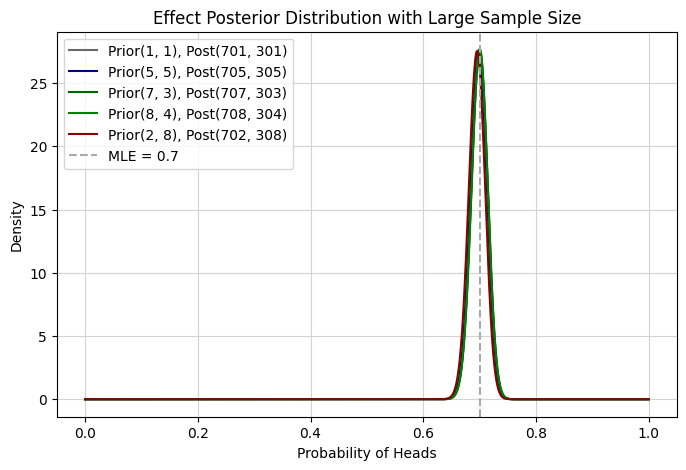

In [8]:
# 事前分布を仮定
prior_cases = [
    (1, 1),      # 事前知識なし
    (5, 5),      # 普通のコイン寄り
    (7, 3),      # 平均的な成功確率が0.7
    (8, 4),      # 事前にコインが10回投げて7回表が出ることを想定
    (2, 8),      # 裏が出やすい
]

# 観測値
n = 1000
k = 700
MLE = k / n

# pを設定
p = np.linspace(0, 1, 1000)

# 描画する
colors = ['dimgray', 'darkblue', 'darkgreen','green', 'darkred']

plt.figure(figsize=(8, 5))
for i, (a_prior, b_prior) in enumerate(prior_cases):
    a_post = a_prior + k
    b_post = b_prior + (n - k)
    
    # MAP推定（事後確率が最大となるパラメータpの点推定）
    map = (a_post - 1) / (a_post + b_post - 2)
    
    posterior_pdf = beta.pdf(p, a_post, b_post)
    
    plt.plot(
        p,
        posterior_pdf,
        color=colors[i],
        label=f'Prior({a_prior}, {b_prior}), Post({a_post}, {b_post})'
    )

    lower, upper = beta.ppf([0.025, 0.975], a_post, b_post)
    print(f'Prior: Beta({a_prior}, {b_prior})',f'MAP: {map:.3f}','下側2.5%点: ', round(lower,3), '/','上側97.5%点: ', round(upper,3))

plt.axvline(
    MLE,
    color='darkgray',
    linestyle='--',
    linewidth=1.5,
    label=f'MLE = {MLE:.1f}'
)

plt.xlabel('Probability of Heads')
plt.ylabel('Density')
plt.title('Effect Posterior Distribution with Large Sample Size')
plt.legend()
plt.grid(True, color='lightgray')
plt.show()

## 7. 補足

#### 3.1 最尤推定の導出

>The likelihood function is:
>
>***L(p) = C(n,k) * p^k * (1-p)^(n-k)***
>
>Taking the log:
>
>***log L(p) = log C(n,k) + k log p + (n-k) log (1-p)***
>
>Differentiating with respect to p:
>
>***d/dp log L(p) = k / p - (n-k) / (1-p)***
>
>Setting this derivative equal to zero:
>
>***k/p = (n-k) / (1-p)***
>
>Splbing for p gives:
>
>***p = k / n***


#### 5.4 事後分布の導出
- ベイズ推定では、尤度を用いて事前分布を更新し、事後分布を得る。
- 事前分布を Beta(a, b)、尤度を二項分布とする。

> 事前分布：p ~ Beta(a, b)

> 尤度：L(p) ∝ p^k (1-p)^(n-k)

ベイズの定理より、

> P(p|k) ∝ P(k|p) P(p)

したがって、

> P(p|k) ∝ p^k (1-p)^(n-k) × p^(a-1)(1-p)^(b-1)

整理すると、

> P(p|k) ∝ p^(a+k-1)(1-p)^(b+n-k-1)

これは Beta(a+k, b+n-k) の形であるため、

> p | k ~ Beta(a+k, b+n-k)


#### 5.6 信用区間について
| 区間       | 立場     | パラメータの扱い        | 解釈                          |
| -------- | ------ | --------------- | --------------------------- |
| **信用区間** | ベイズ統計  | パラメータを確率変数として扱う | 観測データのもとで、p がその区間にある確率が95%  |
| **信頼区間** | 頻度主義統計 | パラメータは固定値として扱う  | 同じ手順を繰り返すと、作った区間の95%が真のpを含む |

#### 6.2 事前分布の置き方

- a - 1 = 成功の事前的な回数
- b - 1 = 失敗の事前的な回数

| 事前分布      |    平均 |   最頻値 | 解釈                   |
| --------- | ----: | ----: | -------------------- |
| Beta(7,3) | 0.700 | 0.750 | 平均的に成功確率0.7だと考える     |
| Beta(8,4) | 0.667 | 0.700 | 最もありそうな成功確率が0.7だと考える (事前に10回分くらいの情報量で、7回成功・3回失敗くらいを想定) |
